In [8]:
"""
Bridge Health Monitor — ML Training Pipeline
=============================================
What this script does, in plain English:
  1. Loads vibration data (CSV) collected from the MPU-6050 accelerometer
  2. Converts raw time-domain readings into frequency-domain features (FFT)
     — because a cracked bridge sounds different at specific frequencies
  3. Trains a small neural network classifier (Normal vs Anomaly)
  4. Evaluates accuracy on held-out test data
  5. Converts the model to TFLite with int8 quantisation so it fits on an ESP32
  6. Saves the final .tflite file ready for flashing

Requirements:
  pip install numpy pandas scikit-learn tensorflow matplotlib

Data format expected (CSV columns):
  timestamp, ax, ay, az, label
  label: 0 = normal, 1 = anomaly (crack / unusual resonance)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
import os


In [9]:
# ─────────────────────────────────────────────
# STEP 0 — Configuration
# ─────────────────────────────────────────────
DATA_PATH    = "vibration_data.csv"   # your collected CSV file
MODEL_PATH   = "bridge_model.tflite"  # output TFLite model
SAMPLE_RATE  = 100      # MPU-6050 samples per second (set in Arduino sketch)
WINDOW_SIZE  = 128      # number of samples per analysis window (~1.28 seconds)
N_FFT_BINS   = 32       # how many FFT frequency buckets to use as features
EPOCHS       = 50       # training iterations
BATCH_SIZE   = 16       # samples per gradient update

# ─────────────────────────────────────────────
# STEP 1 — Generate synthetic data if no CSV yet
# ─────────────────────────────────────────────
# During Week 1 you will replace this with your real collected data.
# This synthetic generator lets you run and test the full pipeline immediately.

def generate_synthetic_data(n_samples=500):
    """
    Simulates MPU-6050 readings:
      Normal  : low-frequency vibration (truck traffic), ~5-15 Hz dominant
      Anomaly : shifted dominant frequency + extra harmonics (crack resonance)
    """
    print("[DATA] No CSV found — generating synthetic data for testing...")
    t = np.linspace(0, WINDOW_SIZE / SAMPLE_RATE, WINDOW_SIZE)
    rows = []

    for i in range(n_samples):
        label = np.random.randint(0, 2)  # 0=normal, 1=anomaly

        if label == 0:
            # Normal: dominant frequency 8 Hz, small noise
            freq = np.random.uniform(6, 10)
            ax = 0.5 * np.sin(2 * np.pi * freq * t) + 0.05 * np.random.randn(WINDOW_SIZE)
            ay = 0.3 * np.sin(2 * np.pi * freq * t + 0.5) + 0.05 * np.random.randn(WINDOW_SIZE)
            az = 1.0 + 0.1 * np.random.randn(WINDOW_SIZE)   # gravity offset + noise

        else:
            # Anomaly: frequency drops (structural loosening) + new harmonic
            freq = np.random.uniform(2, 5)   # lower dominant frequency
            ax = (0.8 * np.sin(2 * np.pi * freq * t) +
                  0.4 * np.sin(2 * np.pi * freq * 3 * t) +   # 3rd harmonic appears
                  0.1 * np.random.randn(WINDOW_SIZE))
            ay = (0.5 * np.sin(2 * np.pi * freq * t + 1.0) +
                  0.1 * np.random.randn(WINDOW_SIZE))
            az = 1.0 + 0.15 * np.random.randn(WINDOW_SIZE)

        for j in range(WINDOW_SIZE):
            rows.append({
                "timestamp": i * WINDOW_SIZE + j,
                "ax": ax[j], "ay": ay[j], "az": az[j],
                "label": label
            })

    df = pd.DataFrame(rows)
    df.to_csv(DATA_PATH, index=False)
    print(f"[DATA] Saved {n_samples * WINDOW_SIZE} rows to {DATA_PATH}")
    return df

In [10]:
# ─────────────────────────────────────────────
# STEP 2 — Load and window the data
# ─────────────────────────────────────────────

def load_and_window(df):
    """
    Splits the continuous stream of accelerometer readings into
    fixed-size windows. Each window becomes one training sample.
    Label for a window = majority label within that window.
    """
    print("[PREP] Windowing data...")
    X_windows, y_labels = [], []

    for start in range(0, len(df) - WINDOW_SIZE, WINDOW_SIZE // 2):  # 50% overlap
        window = df.iloc[start : start + WINDOW_SIZE]
        if len(window) < WINDOW_SIZE:
            break
        ax = window["ax"].values
        ay = window["ay"].values
        az = window["az"].values
        label = int(window["label"].mode()[0])   # majority class in window
        X_windows.append((ax, ay, az))
        y_labels.append(label)

    print(f"[PREP] Created {len(X_windows)} windows of size {WINDOW_SIZE}")
    return X_windows, np.array(y_labels)

In [11]:
# ─────────────────────────────────────────────
# STEP 3 — Extract FFT features
# ─────────────────────────────────────────────

def extract_fft_features(X_windows):
    """
    Why FFT?
    --------
    Raw accelerometer values (e.g. 0.45 g, 0.47 g, 0.42 g...) are hard for a
    model to learn from directly. FFT converts them into a spectrum: how much
    energy is present at each frequency (2 Hz? 8 Hz? 20 Hz?).
    A healthy bridge has energy concentrated at low frequencies (traffic).
    A damaged bridge develops energy at new frequencies (resonance shifts).
    This makes the classifier's job much easier.

    Feature vector per window = [FFT_ax | FFT_ay | FFT_az]
    Size = 3 * N_FFT_BINS = 96 features
    """
    features = []
    for (ax, ay, az) in X_windows:
        fft_ax = np.abs(np.fft.rfft(ax))[:N_FFT_BINS]
        fft_ay = np.abs(np.fft.rfft(ay))[:N_FFT_BINS]
        fft_az = np.abs(np.fft.rfft(az))[:N_FFT_BINS]
        feature_vec = np.concatenate([fft_ax, fft_ay, fft_az])
        features.append(feature_vec)
    return np.array(features, dtype=np.float32)

In [12]:
# ─────────────────────────────────────────────
# STEP 4 — Build the neural network
# ─────────────────────────────────────────────

def build_model(input_dim):
    """
    Small 3-layer network designed to fit within ESP32 RAM (~320 KB).
    Architecture: Dense(64) → Dense(32) → Dense(1, sigmoid)
    Total parameters: ~6,500 — tiny but effective for this task.
    """
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.2),          # prevents overfitting on small dataset
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation="sigmoid")   # output: 0=normal, 1=anomaly
    ], name="bridge_health_classifier")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    model.summary()
    return model

In [13]:
# ─────────────────────────────────────────────
# STEP 5 — Convert to TFLite with int8 quantisation
# ─────────────────────────────────────────────

def convert_to_tflite(model, X_train_scaled):
    """
    Why quantise?
    -------------
    By default, neural network weights are 32-bit floats.
    int8 quantisation converts them to 8-bit integers.
    This reduces model size by ~4x and inference time by ~2x on the ESP32,
    with only a tiny drop in accuracy (usually < 1%).

    The representative_dataset function shows the converter what typical
    input values look like, so it can calculate the right scaling factors.
    """
    print("[CONVERT] Converting to TFLite int8...")

    def representative_dataset():
        for i in range(min(200, len(X_train_scaled))):
            sample = X_train_scaled[i].reshape(1, -1).astype(np.float32)
            yield [sample]

    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()

    with open(MODEL_PATH, "wb") as f:
        f.write(tflite_model)

    size_kb = len(tflite_model) / 1024
    print(f"[CONVERT] Saved {MODEL_PATH} ({size_kb:.1f} KB)")
    print(f"[CONVERT] ESP32 has ~320 KB RAM — model uses {size_kb:.1f} KB ({size_kb/320*100:.1f}%)")
    return tflite_model


In [14]:
# ─────────────────────────────────────────────
# STEP 6 — Plot results (for your report)
# ─────────────────────────────────────────────

def plot_training(history, X_test, y_test, model, scaler):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Bridge Health Monitor — Training Results", fontsize=13)

    # Accuracy curve
    axes[0].plot(history.history["accuracy"],     label="Train accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val accuracy")
    axes[0].set_title("Model accuracy over epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Loss curve
    axes[1].plot(history.history["loss"],     label="Train loss")
    axes[1].plot(history.history["val_loss"], label="Val loss")
    axes[1].set_title("Loss over epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # Confusion matrix
    y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
    cm = confusion_matrix(y_test, y_pred)
    im = axes[2].imshow(cm, cmap="Blues")
    axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
    axes[2].set_xticklabels(["Normal","Anomaly"])
    axes[2].set_yticklabels(["Normal","Anomaly"])
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")
    axes[2].set_title("Confusion matrix")
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, cm[i,j], ha="center", va="center",
                         color="white" if cm[i,j] > cm.max()/2 else "black")

    plt.tight_layout()
    plt.savefig("training_results.png", dpi=150)
    print("[PLOT] Saved training_results.png — use this in your report!")
    plt.show()

[DATA] No CSV found — generating synthetic data for testing...
[DATA] Saved 76800 rows to vibration_data.csv
[PREP] Windowing data...
[PREP] Created 1198 windows of size 128

[INFO] Dataset: 1198 samples, 96 features each
[INFO] Class balance: 764 normal, 434 anomaly

[INFO] Saved scaler_params.json — embed mean/scale values in Arduino sketch


Model: "bridge_health_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,321 (32.50 KB)

 Trainable params: 8,321 (32.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7458 - loss: 0.5589 - val_accuracy: 0.8806 - val_loss: 0.3154
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9033 - loss: 0.2449 - val_accuracy: 0.9194 - val_loss: 0.1954
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9630 - loss: 0.1482 - val_accuracy: 0.9611 - val_loss: 0.1126
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9797 - loss: 0.0802 - val_accuracy: 0.9778 - val_loss: 0.0727
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9916 - loss: 0.0495 - val_accuracy: 0.9889 - val_loss: 0.0476
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9905 - loss: 0.0328 - val_accuracy: 0.9861 - val_loss: 0.0373
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9976 - loss: 0.0191 - val_accuracy: 0.9861 - val_loss: 0.0384
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9988 - loss: 0.0129 - val_accuracy: 0.9889 - val_loss

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[PLOT] Saved training_results.png — use this in your report!


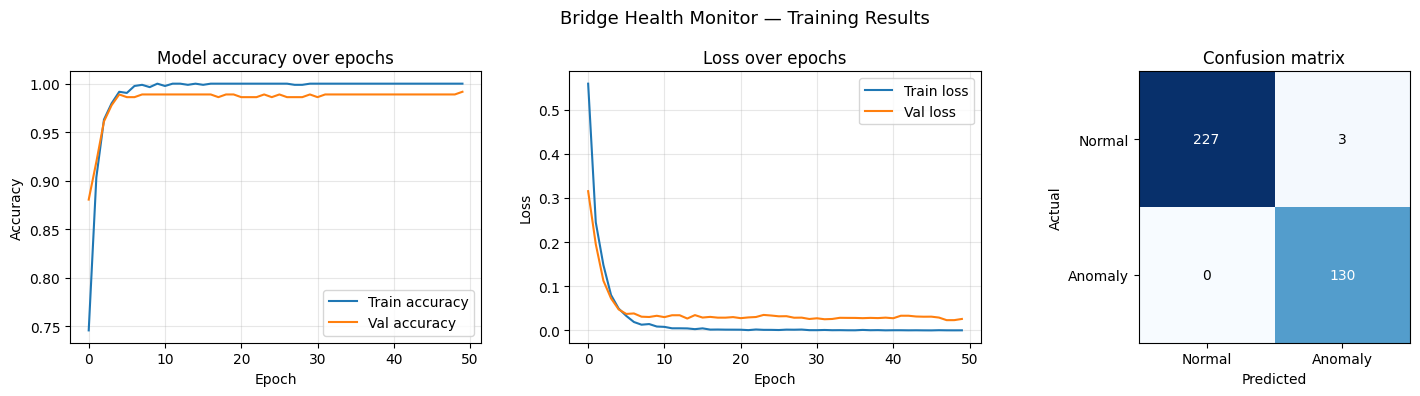


[DONE] Files ready:
  bridge_model.tflite         → copy to Arduino sketch folder
  scaler_params.json  → embed mean/scale in Arduino sketch
  training_results.png → include in project report


In [15]:

# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

if __name__ == "__main__":

    # Load or generate data
    if os.path.exists(DATA_PATH):
        print(f"[DATA] Loading {DATA_PATH}...")
        df = pd.read_csv(DATA_PATH)
    else:
        df = generate_synthetic_data(n_samples=600)

    # Window + extract features
    X_windows, y = load_and_window(df)
    X_features   = extract_fft_features(X_windows)

    print(f"\n[INFO] Dataset: {X_features.shape[0]} samples, "
          f"{X_features.shape[1]} features each")
    print(f"[INFO] Class balance: {np.sum(y==0)} normal, {np.sum(y==1)} anomaly\n")

    # Split into train (70%) and test (30%)
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y, test_size=0.3, random_state=42, stratify=y
    )

    # Scale features (zero mean, unit variance — important for neural nets)
    scaler  = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # Save scaler parameters — you need these for the Arduino sketch!
    scaler_params = {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist()
    }
    import json
    with open("scaler_params.json", "w") as f:
        json.dump(scaler_params, f)
    print("[INFO] Saved scaler_params.json — embed mean/scale values in Arduino sketch")

    # Build and train
    model = build_model(input_dim=X_features.shape[1])
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    # Evaluate
    print("\n[EVAL] Classification report on test set:")
    y_pred = (model.predict(X_test_scaled) > 0.5).astype(int).flatten()
    print(classification_report(y_test, y_pred,
                                 target_names=["Normal", "Anomaly"]))

    # Convert to TFLite
    convert_to_tflite(model, X_train_scaled)

    # Plot and save figures for report
    plot_training(history, X_test_scaled, y_test, model, scaler)

    print("\n[DONE] Files ready:")
    print(f"  {MODEL_PATH}         → copy to Arduino sketch folder")
    print(f"  scaler_params.json  → embed mean/scale in Arduino sketch")
    print(f"  training_results.png → include in project report")
